In [2]:
import jupyter_utils as ju
import straindesign as sd
import numpy as np
import matplotlib as plt
base_dir = Path.home() / "Documents" / "PhD" / "10-19 Research" / "11 Data" / "11.09_Models"
model = ju.load_model(base_dir,"Experiment", "250723_iABA974_BLG.sbml")

In [ ]:
model.objective = "EX_BLG_x1_e"
model.optimize()
model.reactions.get_by_id('Growth').bounds = 0.0, 0.0
# model.reactions.get_by_id('EX_h2_e').bounds = -50.0, 1000.0
# model.reactions.get_by_id('EX_o2_e').bounds = -100.0, 1000.0
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,2.085,1,100.00%
h2_e,EX_h2_e,18.28,0,0.00%
nh4_e,EX_nh4_e,0.5482,0,0.00%
o2_e,EX_o2_e,7.076,0,0.00%
so4_e,EX_so4_e,0.01078,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
BLG_x1_e,EX_BLG_x1_e,-0.4206,0,0.00%
h2o_e,EX_h2o_e,-17.35,0,0.00%


This notebook will mainly use the strain design toolbox

## production envelope

Production envelopes project the solution space of steady-state flux vectors onto the dimensions of growth rate and product synthesis rate. 

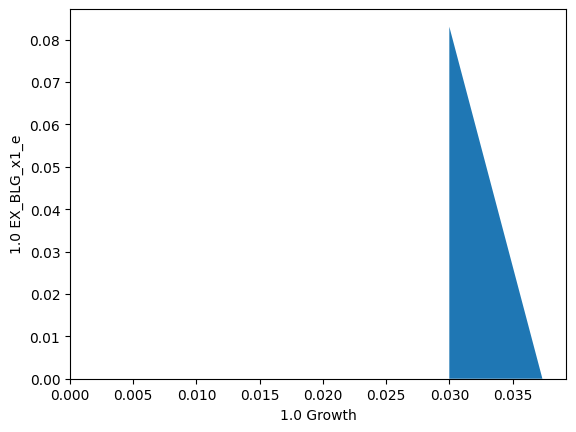

([[0.03, np.float64(0.0)],
  [0.03018879205128205, np.float64(0.0)],
  [0.030377584102564102, np.float64(0.0)],
  [0.030566376153846154, np.float64(0.0)],
  [0.030755168205128205, np.float64(0.0)],
  [0.030943960256410257, np.float64(0.0)],
  [0.03113275230769231, np.float64(0.0)],
  [0.03132154435897436, np.float64(0.0)],
  [0.03151033641025641, np.float64(0.0)],
  [0.03169912846153846, np.float64(0.0)],
  [0.031887920512820515, np.float64(0.0)],
  [0.032076712564102564, np.float64(0.0)],
  [0.03226550461538462, np.float64(0.0)],
  [0.03245429666666667, np.float64(0.0)],
  [0.032643088717948715, np.float64(0.0)],
  [0.03283188076923077, np.float64(0.0)],
  [0.03302067282051282, np.float64(0.0)],
  [0.03320946487179487, np.float64(0.0)],
  [0.03339825692307692, np.float64(0.0)],
  [0.03358704897435898, np.float64(0.0)],
  [0.033775841025641025, np.float64(0.0)],
  [0.03396463307692308, np.float64(0.0)],
  [0.03415342512820513, np.float64(0.0)],
  [0.03434221717948718, np.float64(0.0)],

In [4]:
sd.plot_flux_space(model,('Growth','EX_BLG_x1_e'))

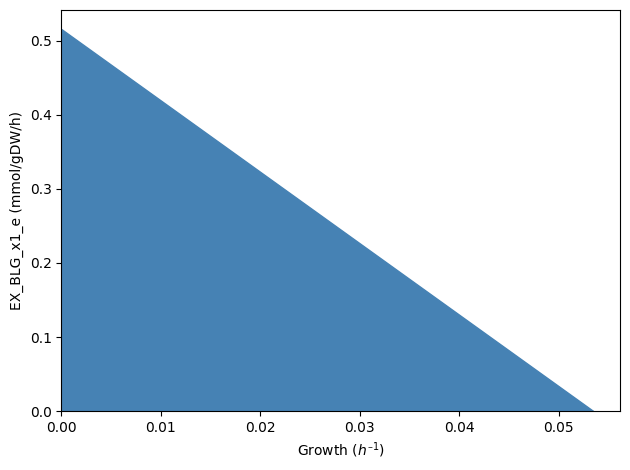

In [3]:
import matplotlib.pyplot as plt
# Define reactions
biomass_rxn = "Growth"
product_rxn = "EX_BLG_x1_e"
model.reactions.get_by_id('ATPM').bounds = 4.5, 1000.0
model.objective = biomass_rxn
sol = model.optimize()
# Range of growth rates
growth_rates = np.linspace(0,sol.fluxes[biomass_rxn], 50)
product_fluxes = []

for gr in growth_rates:
    with model:
        # Fix growth rate
        model.reactions.get_by_id(biomass_rxn).lower_bound = gr
        model.reactions.get_by_id(biomass_rxn).upper_bound = gr
        
        # Maximize product
        model.objective = product_rxn
        sol = model.optimize()
        product_fluxes.append(sol.objective_value if sol.status == 'optimal' else 0)

# Plot

plt.fill_between(growth_rates, product_fluxes, color='steelblue')
plt.xlabel('Growth ($h^{–1}$)')
plt.ylabel(f'{product_rxn} (mmol/gDW/h)')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

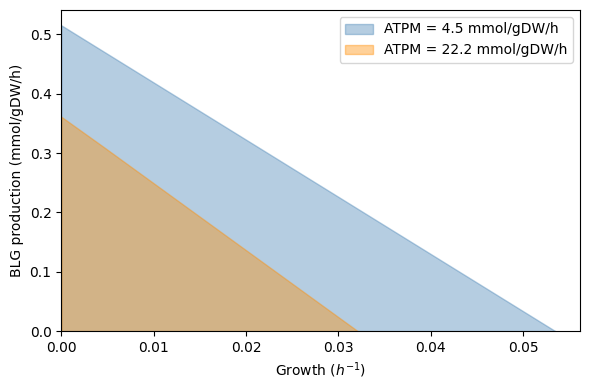

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def production_envelope(model, biomass_rxn, product_rxn, atpm_value, color, label):
    # Set ATP maintenance
    model.reactions.get_by_id('ATPM').bounds = (atpm_value, 1000.0)

    # Optimize for biomass to get max growth
    model.objective = biomass_rxn
    sol = model.optimize()

    growth_rates = np.linspace(0, sol.fluxes[biomass_rxn], 50)
    product_fluxes = []

    for gr in growth_rates:
        with model:
            # Fix growth rate
            model.reactions.get_by_id(biomass_rxn).lower_bound = gr
            model.reactions.get_by_id(biomass_rxn).upper_bound = gr

            # Maximize product
            model.objective = product_rxn
            sol = model.optimize()
            product_fluxes.append(sol.objective_value if sol.status == 'optimal' else 0)

    # Plot
    plt.fill_between(growth_rates, product_fluxes, color=color, alpha=0.4, label=label)


# Define reactions
biomass_rxn = "Growth"
product_rxn = "EX_BLG_x1_e"

# Plot envelopes for two ATPM values
plt.figure(figsize=(6,4))
production_envelope(model, biomass_rxn, product_rxn, atpm_value=4.5, color="steelblue", label="ATPM = 4.5 mmol/gDW/h")
production_envelope(model, biomass_rxn, product_rxn, atpm_value=22.2, color="darkorange", label="ATPM = 22.2 mmol/gDW/h")

plt.xlabel('Growth ($h^{-1}$)')
plt.ylabel(f'BLG production (mmol/gDW/h)')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

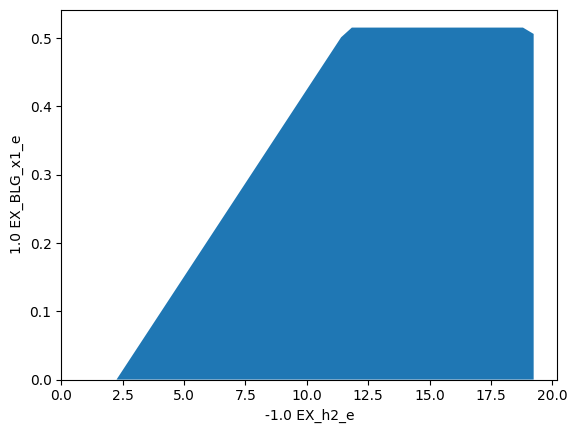

([[2.25, np.float64(0.0)],
  [2.6856708394871793, np.float64(0.0)],
  [3.121341678974359, np.float64(0.0)],
  [3.5570125184615384, np.float64(0.0)],
  [3.992683357948718, np.float64(0.0)],
  [4.4283541974358975, np.float64(0.0)],
  [4.864025036923077, np.float64(0.0)],
  [5.299695876410256, np.float64(0.0)],
  [5.735366715897436, np.float64(0.0)],
  [6.171037555384615, np.float64(0.0)],
  [6.606708394871795, np.float64(0.0)],
  [7.042379234358974, np.float64(0.0)],
  [7.478050073846154, np.float64(0.0)],
  [7.913720913333333, np.float64(0.0)],
  [8.349391752820512, np.float64(0.0)],
  [8.785062592307693, np.float64(0.0)],
  [9.220733431794873, np.float64(0.0)],
  [9.656404271282051, np.float64(0.0)],
  [10.09207511076923, np.float64(0.0)],
  [10.52774595025641, np.float64(0.0)],
  [10.96341678974359, np.float64(0.0)],
  [11.399087629230769, np.float64(0.0)],
  [11.834758468717949, np.float64(0.0)],
  [12.270429308205129, np.float64(0.0)],
  [12.706100147692307, np.float64(0.0)],
  [13.

In [28]:
model1 = model.copy()
model1.reactions.get_by_id('ATPM').bounds = 4.5, 1000.0
sd.plot_flux_space(model1,('-EX_h2_e','EX_BLG_x1_e'))

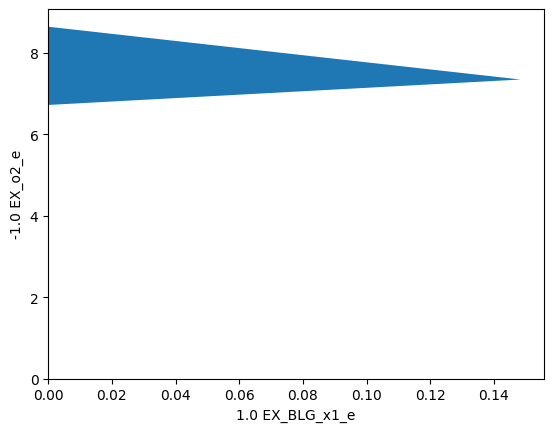

([[0.0, np.float64(6.725716771)],
  [0.003803944871794872, np.float64(6.741743328)],
  [0.007607889743589744, np.float64(6.757769884)],
  [0.011411834615384616, np.float64(6.77379644)],
  [0.015215779487179488, np.float64(6.789822996)],
  [0.01901972435897436, np.float64(6.805849553)],
  [0.02282366923076923, np.float64(6.821876108)],
  [0.026627614102564104, np.float64(6.837902665)],
  [0.030431558974358976, np.float64(6.853929221)],
  [0.03423550384615385, np.float64(6.869955777)],
  [0.03803944871794872, np.float64(6.885982333)],
  [0.041843393589743594, np.float64(6.90200889)],
  [0.04564733846153846, np.float64(6.918035446)],
  [0.04945128333333334, np.float64(6.934062002)],
  [0.05325522820512821, np.float64(6.950088558)],
  [0.057059173076923084, np.float64(6.966115114)],
  [0.06086311794871795, np.float64(6.98214167)],
  [0.06466706282051282, np.float64(6.998168227)],
  [0.0684710076923077, np.float64(7.014194783)],
  [0.07227495256410257, np.float64(7.030221339)],
  [0.0760788

In [14]:
sd.plot_flux_space(model,('EX_BLG_x1_e','-EX_o2_e'))

## 3D plots


A 3-dimensional plot may help tp reveal more complex relationships between fluxes and yields. In the following plot, we analyze the relationship between oxygen uptake, growth rate and ethanol yield.

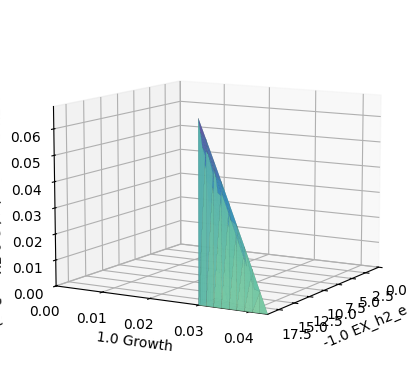

In [18]:
sd.plot_flux_space(model,('-EX_h2_e','Growth',('EX_BLG_x1_e','-EX_co2_e')),points=10);

In [13]:
ju.print_reaction_details(model, 'EX_h2_e')
#sd.plot_flux_space(model,('Growth',('Growth','-EX_co2_e')))



Reaction ID   : EX_h2_e
Name          : EX_h2_e
Equation      : h2_e <-- 
Lower Bound   : -19.4
Upper Bound   : 0.0

Metabolites and Stoichiometry:
 - h2_e           :   -1.0  Name: Hydrogen                                           Charge:   0  Formula: H2

Sum of Charge Balance: 0.0

Associated Genes:
 - None


In [3]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.000185,0,0.00%
cl_e,EX_cl_e,0.000185,0,0.00%
co2_e,EX_co2_e,1.785,1,100.00%
cobalt2_e,EX_cobalt2_e,8.967E-07,0,0.00%
cu2_e,EX_cu2_e,0.000252,0,0.00%
fe2_e,EX_fe2_e,0.0005412,0,0.00%
h2_e,EX_h2_e,17.99,0,0.00%
k_e,EX_k_e,0.006938,0,0.00%
mg2_e,EX_mg2_e,0.0003084,0,0.00%
mn2_e,EX_mn2_e,2.458E-05,0,0.00%


In [2]:
model.objective = 'Growth'
model.optimize()

,fluxes,reduced_costs
EX_25dkglcn_e,0.000000,-2.025297e-01
EX_2ameph_e,0.000000,-5.786563e-02
EX_2m35mdntha_e,0.000000,0.000000e+00
EX_2pglyc_e,0.000000,-5.786563e-02
EX_34dhbz_e,0.000000,-1.499246e-01
...,...,...
CYTHYD,0.000000,-7.101691e-02
Growth,0.037363,-1.500844e-15
BLG_x1_production,0.000000,-1.773062e-01
BLG_x1t,0.000000,0.000000e+00


In [21]:
module_optcouple = sd.SDModule(model,sd.names.OPTCOUPLE,
                              inner_objective='Growth',
                              prod_id='SK_bhb_c',
                              min_gcp=0.3)

import logging
logging.basicConfig(level=logging.INFO)
## Compute strain designs
# allow all gene knockouts except for spontanuos
gko_cost = {g.name:1 for g in model.genes}
#gko_cost.pop('s0001')
# possible knockout of O2
ko_cost = {'EX_o2_e': 1}

sols = sd.compute_strain_designs(model,
                                 sd_modules = module_optcouple,
                                 max_solutions = 1,
                                 max_cost = 15,
                                 gko_cost = gko_cost,
                                 ko_cost = ko_cost,
                                 solution_approach = sd.names.BEST)
# Print solution
print(f"One compressed solution with cost {sols.sd_cost[0]} found and "+\
      f"expanded to {len(sols.gene_sd)} solutions in the uncompressed netork.")
print(f"Example intervention set: {['+'+s if v>0 else '-'+s for s,v in sols.gene_sd[0].items() if v!=0]}")

import matplotlib.pyplot as plt
# Wild-type plot
datapoints, triang, plot1 = sd.plot_flux_space(model,
                                               ('Growth','SK_bhb_c'),
                                               show=False);

# OptKnock design plot
interventions = [[{s:1.0},'=',0.0] for s,v in sols.reaction_sd[0].items() if v < 1]
_,          _,      plot3 = sd.plot_flux_space(model,
                                               ('Growth','SK_bhb_c'),
                                               # The sign of the glucose exchange reaction is flipped since
                                               # reaction is defined in the direction of secretion.
                                               constraints=interventions,
                                               show=False);
plot3.set_facecolor('#FFC000')
plot3.set_edgecolor('#FFC000')
# adjust axes limits and show plot
plot3.axes.set_xlim(0, 1.05*max([a[0] for a in datapoints]))
plot3.axes.set_ylim(0, 1.05*max([a[1] for a in datapoints]))
plt.show()

INFO:root:Preparing strain design computation.
INFO:root:  Using random seed 42231
INFO:root:  Using glpk for solving LPs during preprocessing.
INFO:root:  FVA to identify blocked reactions and irreversibilities.
INFO:root:  FVA(s) to identify essential reactions.
INFO:root:Preprocessing GPR rules (974 genes, 1608 gpr rules).


KeyboardInterrupt: 